In [1280]:
# shell PATH not inherited by VScode, so graphviz's `dot` wasn't found
import os, shutil
os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ.get("PATH", "")
print(shutil.which("dot"))

/opt/homebrew/bin/dot


In [1281]:
import sys; print(sys.executable)

/Users/tomrodger/ml-foundations/.venv/bin/python


In [1282]:

import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import random

%matplotlib inline

In [ ]:
# ---- Notebook for walking through Karpathy Tutorial of Micrograd ----
# Also includes any tests of extra implementations that I wanted to try out

In [1283]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label


    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out
    
    def __radd__(self, other):
        return self + other
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
                self.grad += other.data * out.grad
                other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other): # other * self
        return self * other
    
    def __pow__(self, other):
        assert isinstance (other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += (other*self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __neg__(self): # -(self)
        return self * -1
    
    def __sub__(self, other): # self - other
        return self + (-other)
    
    def tanh(self): 
        x = self.data
        t = (math.exp(2*x) -1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
             self.grad += (1 - (t**2)) * out.grad
        out._backward = _backward
        return out
    
    def relu(self):
        out = Value(max(0, self.data), (self, ), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out
  
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward(): 
            self.grad += out.data * out.grad
        out._backward = _backward

        return out

    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    
    
a = Value(2.0, label='a')
b = Value(-3.0,label='b')
c = Value(10.0,label='c')
d = a*b + c; d.label='d'
e = a*b; e.label='e'
f = Value(-2.0, label='f') 
L = d*f; label='L'
L

Value(data=-8.0)

In [1284]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # for any value in the graph, create a rectangular ('record') node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid +n._op, uid)

    for n1,n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot


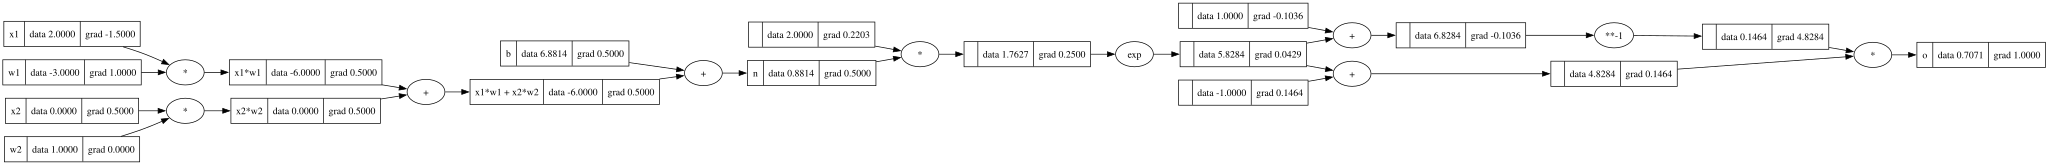

In [1285]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2*n).exp()
o = (e - 1) / (e+1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

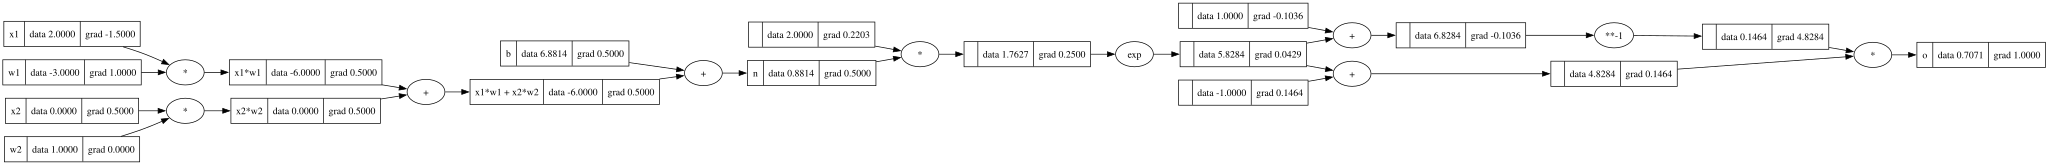

In [1286]:
draw_dot(o)

In [1287]:
import torch

x1 = torch.Tensor([2.0]).double()               ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()               ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()              ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()               ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())


0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [1288]:
class Neuron:
    def __init__(self, nin, nonlin=True): 
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        self.nonlin = nonlin

    def __call__(self, x):
        #w * x + b 
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.relu() if self.nonlin else act
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer: 

    def __init__(self, nin, nout, nonlin=True):
        self.neurons = [Neuron(nin, nonlin=nonlin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

    
class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], nonlin=(i != len(nouts)-1)) 
                       for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x) 
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.1356999862935618)

In [1289]:
xs = [
    [2.0, 3.0, -1.0], 
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets



In [1290]:
for k in range(100):

    # forward pass 
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    for p in n.parameters():
        p.data += -0.02 * p.grad

    print(k, loss.data)

0 3.194187929465813
1 2.447140523985515
2 2.1722209418036384
3 1.9343341773358147
4 1.5621744227556216
5 1.2767149055444997
6 1.0659700466443738
7 0.895243934232992
8 0.7302877526497055
9 0.584279685464682
10 0.45644099914446057
11 0.3469496398088748
12 0.2573020583267095
13 0.18624482925576466
14 0.131737396587483
15 0.09122305027549849
16 0.06330723321998159
17 0.04253721184793375
18 0.028006622388441406
19 0.01821773031082955
20 0.011728723585473316
21 0.007486868100037141
22 0.004746077373856113
23 0.0029920136148714385
24 0.0019298464117069227
25 0.0012135456416745164
26 0.0007569968214796682
27 0.0004720577118280548
28 0.00029454528141549345
29 0.0001894339682041556
30 0.00011974277973157827
31 7.565531465101189e-05
32 4.843589950866773e-05
33 3.256299412774038e-05
34 2.183554772386547e-05
35 1.508951596293467e-05
36 1.1084674338080112e-05
37 8.475532274223255e-06
38 6.742118921861399e-06
39 5.704297592114832e-06
40 4.96724455225117e-06
41 4.4715000284934145e-06
42 4.132289252472

In [1291]:
ypred

[Value(data=0.999487062889759),
 Value(data=-1.0000384496057144),
 Value(data=-0.9999610585623976),
 Value(data=1.0006049347158956)]

In [1292]:
X, y = make_moons(n_samples=100, noise=0.1)
y = y*2 - 1   # {0,1} → {-1,1}

X, y = make_moons(n_samples=100, noise=0.1)
y = y*2 - 1 

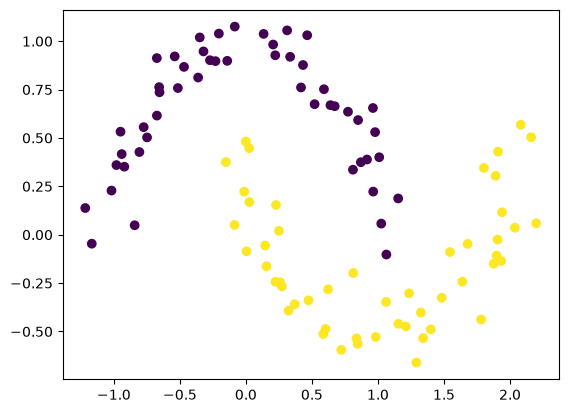

In [1293]:
plt.scatter(X[:,0], X[:,1], c=y)


In [1294]:
n = MLP(2, [16, 16, 1])
n = MLP(2, [16, 16, 1])
